In [2]:
import pandas as pd
import numpy as np

In [3]:
filename = 'diabetes_dataset.csv'
df = pd.read_csv(filename)
df.head(1)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1


In [4]:
df['systolic_diastolic_ratio'] = df['systolic_bp'] / df['diastolic_bp']
df['hdl_ldl_ratio'] = df['hdl_cholesterol'] / df['ldl_cholesterol']
df['glucose_after_eating_to_fasting_ratio'] = df['glucose_postprandial'] / df['glucose_fasting']
df ['bmi_to_age_ratio'] = df['bmi'] / df['age']
df['bmi_cholesterol_ratio'] = df['bmi'] / df['cholesterol_total']

In [5]:
input_cols = ['age', 'gender','smoking_status', 'alcohol_consumption_per_week',
       'sleep_hours_per_day' , 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi','cholesterol_total' , 'triglycerides', 'insulin_level', 'hba1c', 
       'physical_activity_minutes_per_week', 'diet_score',
       'systolic_diastolic_ratio', 'hdl_ldl_ratio',
       'glucose_after_eating_to_fasting_ratio', 'bmi_to_age_ratio',
       'bmi_cholesterol_ratio']

target_col = 'diabetes_stage'

In [6]:
numerical_cols = df[input_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df[input_cols].select_dtypes(include=['object']).columns.tolist()

In [7]:
from sklearn.model_selection import train_test_split
X = df[input_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train.shape, X_test.shape

((90000, 20), (10000, 20))

In [8]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[cat_cols])
ohe.categories_

[array(['Female', 'Male', 'Other'], dtype=object),
 array(['Current', 'Former', 'Never'], dtype=object)]

In [9]:
X_train_ohe = ohe.transform(X_train[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

In [10]:
input_cols_final = numerical_cols + ohe.get_feature_names_out(cat_cols).tolist()

In [11]:
X_train_final = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(cat_cols), index=X_train.index)
X_train_final[numerical_cols] = X_train[numerical_cols]
X_test_final = pd.DataFrame(X_test_ohe, columns=ohe.get_feature_names_out(cat_cols), index=X_test.index)
X_test_final[numerical_cols] = X_test[numerical_cols]
X_train_final.head()

,gender_Female,gender_Male,gender_Other,smoking_status_Current,smoking_status_Former,smoking_status_Never,age,alcohol_consumption_per_week,sleep_hours_per_day,family_history_diabetes,...,triglycerides,insulin_level,hba1c,physical_activity_minutes_per_week,diet_score,systolic_diastolic_ratio,hdl_ldl_ratio,glucose_after_eating_to_fasting_ratio,bmi_to_age_ratio,bmi_cholesterol_ratio
51994,1.0,0.0,0.0,0.0,0.0,1.0,67,2,8.9,0,...,93,14.90,5.86,34,5.0,2.015385,0.405405,1.731183,0.434328,0.125431
77540,1.0,0.0,0.0,0.0,0.0,1.0,39,1,7.1,0,...,129,3.49,6.82,95,8.6,1.739130,0.420168,1.542857,0.607692,0.119697
16382,1.0,0.0,0.0,1.0,0.0,0.0,36,5,6.1,0,...,167,15.47,7.10,419,5.0,1.585714,0.650000,1.596491,0.691667,0.141477
83439,1.0,0.0,0.0,0.0,0.0,1.0,62,1,7.2,0,...,112,13.97,7.50,55,2.6,1.686047,0.388350,1.458015,0.574194,0.189362
61618,1.0,0.0,0.0,1.0,0.0,0.0,31,3,6.8,0,...,98,7.59,7.40,138,6.1,1.541667,0.343511,1.660714,1.054839,0.151389


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

In [13]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=200,
    random_state=42)
model.fit(X_train_final, y_train_enc)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009687 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3009
[LightGBM] [Info] Number of data points in the train set: 90000, number of used features: 24
[LightGBM] [Info] Start training from score -5.894136
[LightGBM] [Info] Start training from score -2.528510
[LightGBM] [Info] Start training from score -1.145809
[LightGBM] [Info] Start training from score -6.725434
[LightGBM] [Info] Start training from score -0.513663


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [14]:
model.score(X_test_final, y_test_enc)

0.8735

In [15]:
def max_depth_error(md):
    model = LGBMClassifier(n_estimators=200, max_depth=md, random_state=42)
    model.fit(X_train_final, y_train_enc)
    error = 1 - model.score(X_test_final, y_test_enc)
    return {'max_depth': md, 'error': error}

In [16]:
md_error_df = pd.DataFrame([max_depth_error(md) for md in range(1,31)])
md_error_df.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007430 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3009
[LightGBM] [Info] Number of data points in the train set: 90000, number of used features: 24
[LightGBM] [Info] Start training from score -5.894136
[LightGBM] [Info] Start training from score -2.528510
[LightGBM] [Info] Start training from score -1.145809
[LightGBM] [Info] Start training from score -6.725434
[LightGBM] [Info] Start training from score -0.513663
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

,max_depth,error
0,1,0.1269
1,2,0.1271
2,3,0.1265
3,4,0.1256
4,5,0.1272


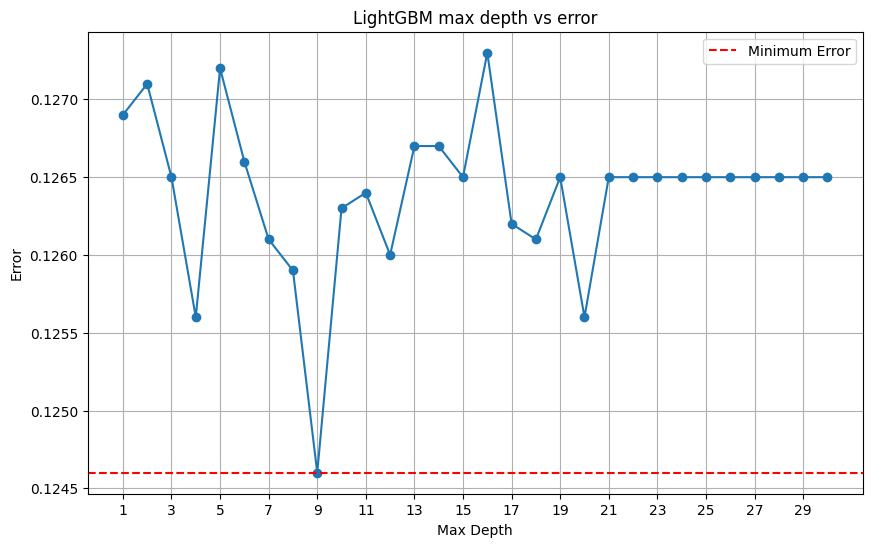

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(md_error_df['max_depth'], md_error_df['error'], marker = 'o')
plt.title('LightGBM max depth vs error')
plt.xlabel('Max Depth')
plt.ylabel('Error')
plt.xticks(np.arange(1,31,2))
plt.axhline(y=md_error_df['error'].min(), color='r', linestyle='--', label='Minimum Error')
plt.legend()
plt.grid()
plt.show()

In [18]:
# minimum error for max_depth = 9

model = LGBMClassifier(
    n_estimators=200,
    max_depth=9,
    random_state=42
)

model.fit(X_train_final, y_train_enc)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3009
[LightGBM] [Info] Number of data points in the train set: 90000, number of used features: 24
[LightGBM] [Info] Start training from score -5.894136
[LightGBM] [Info] Start training from score -2.528510
[LightGBM] [Info] Start training from score -1.145809
[LightGBM] [Info] Start training from score -6.725434
[LightGBM] [Info] Start training from score -0.513663
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,9
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [19]:
model.score(X_test_final, y_test_enc)

0.8754

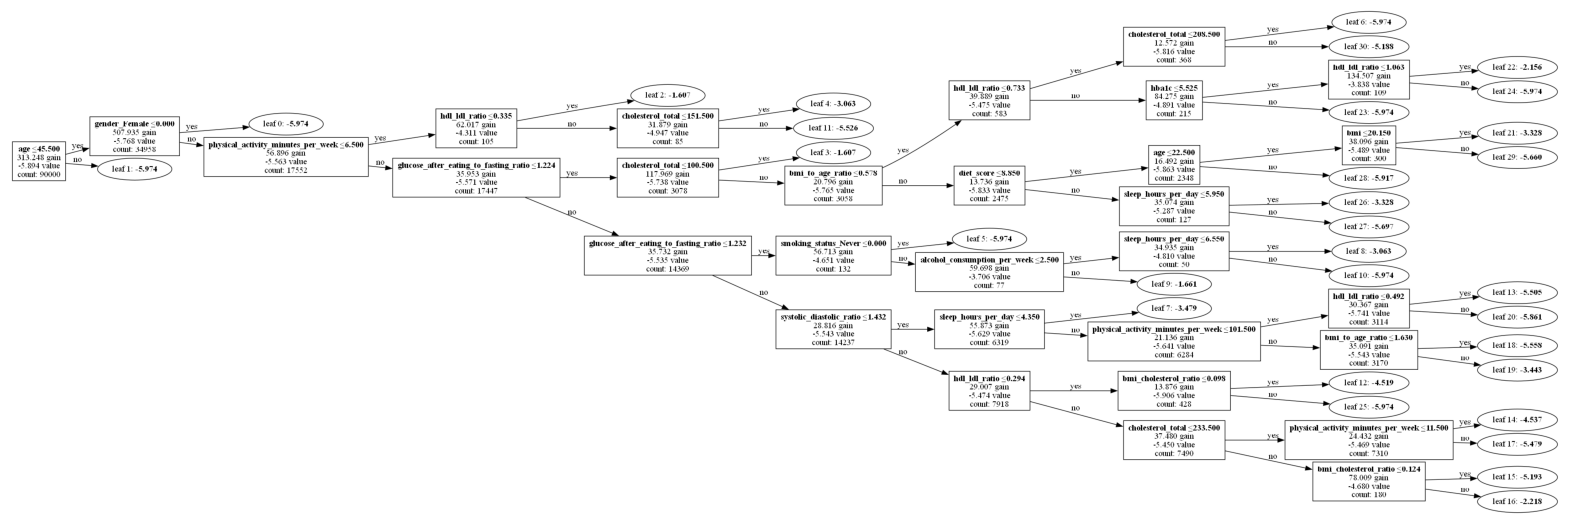

In [20]:
import lightgbm as lgb
ax = lgb.plot_tree(model, tree_index=0, figsize=(20, 10), show_info=['split_gain', 'internal_value', 'internal_count'])
plt.show()